In [1]:
'distrito_id' == 2
'seccion_id' == 125

False

In [2]:
import pandas as pd
import os

In [3]:
# elecciones_ppales = pd.read_csv('./../datos/out/elecciones_ppales.csv')
# elecciones_ppales

In [4]:

# Directory containing the datasets
directory = './../datos/BD/'

# Initialize an empty DataFrame
df_concatenated = pd.DataFrame()

# Loop through files in the directory
for filename in os.listdir(directory):

    if filename.startswith('votos_eleccion'):
        # Load the dataset
        filepath = os.path.join(directory, filename)
        # print(filepath)
        df = pd.read_csv(filepath)
        
        # Filter rows based on conditions
        filtered_df = df[(df['distrito_id'] == 2) & (df['seccion_id'] == 125)]
        
        # Concatenate filtered data into the main DataFrame
        df_concatenated = pd.concat([df_concatenated, filtered_df])

# Reset the index of the concatenated DataFrame
df_concatenated = df_concatenated.reset_index(drop=True)
df_concatenated.shape

/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)
/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)
/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)
/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)
/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)
/tmp/ipykernel_242789/4015105131.py:14: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = 

(250905, 12)

In [5]:
data = df_concatenated
data = data.loc[data.eleccion_id != 1] ## paso 2011 tiene problemas
# data.to_csv('./../datos/out/municipal_2_125.csv', index = False)

In [6]:
# data.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre', 'lista_nombre'])['votos_cantidad'].sum().sort_values().head(20)

In [7]:
# # data.nunique()

# distrito_id               1
# seccionprovincial_id      1
# seccion_id                1
# circuito_id              10
# mesa_id                 285
# cargo_id                 10
# agrupacion_id            98
# agrupacion_nombre        97
# lista_numero             92
# lista_nombre            150
# votos_tipo                6
# votos_cantidad          267
# eleccion_id              17
# dtype: int64

In [8]:
# ## Cantidad de circuitos y mesas
# circuito_id              10
# mesa_id                 285

In [9]:
pd.options.display.max_rows = 99

In [10]:
data.head()

,distrito_id,seccionprovincial_id,seccion_id,circuito_id,mesa_id,cargo_id,agrupacion_id,agrupacion_nombre,lista_numero,votos_tipo,votos_cantidad,eleccion_id
0,2,2.0,125,001018,220,5,NaN,NaN,NaN,IMPUGNADO,0,5
1,2,2.0,125,001018,221,5,NaN,NaN,NaN,IMPUGNADO,0,5
2,2,2.0,125,001017,183,5,NaN,NaN,NaN,IMPUGNADO,0,5
3,2,2.0,125,001017,172,5,NaN,NaN,NaN,IMPUGNADO,0,5
4,2,2.0,125,001015,134,5,NaN,NaN,NaN,IMPUGNADO,0,5


In [11]:
table = data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo'])['votos_cantidad'].sum()

table = table.reset_index()

# eleccion_id	cargo_id	votos_tipo	votos_cantidad
# 0	0	1	BLANCO	2095
# 1	0	1	IMPUGNADO	1
# 2	0	1	NULO	346
# 3	0	1	POSITIVO	65448

In [12]:
import pandas as pd

# Load the tables
eleccion = pd.read_csv('./../datos/BD/eleccion_tags.csv')
cargo = pd.read_csv('./../datos/BD/cargo_tags.csv')

eleccion_cargo = data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo'])['votos_cantidad'].sum().reset_index()

# Merge with the 'eleccion' and 'cargo' table
eleccion_cargo = eleccion_cargo.merge(eleccion, on='eleccion_id', how='left').merge(cargo, on='cargo_id', how='left')

tabla = eleccion_cargo.set_index(['año', 'eleccion_tag', 'cargo_nombre', 'votos_tipo'])['votos_cantidad'].unstack()
show = tabla.loc[tabla.POSITIVO > 40000][['POSITIVO', 'BLANCO', 'NULO']]
show.to_csv('./municipal/validos_zarate.csv')
show.round(-2).astype(int)

votos_tipo                                              POSITIVO  BLANCO  NULO
año  eleccion_tag cargo_nombre                                                
2011 GRAL11n      Concejal                                 50300    4600   300
                  Diputado Nacional                        61100    5800   300
                  Gobernador                               59800    7200   400
                  Presidente                               65400    2100   300
                  Senador Nacional                         61800    5100   300
                  Senador Provincial                       59000    7800   400
2013 GRAL13n      Diputado Nacional                        67800    4400   800
                  Intendente                               66200    6400   800
     PASO13n      Diputado Nacional                        60900    2300  1000
                  Diputado Provincial                      58100    4300  1100
                  Intendente                               50900    3900  1100
2015 BLTG15n      Presidente                               73100    1200   600
     GRAL15n      Concejal                                 66800    5700   400
                  Diputado Nacional                        65100    7600   300
                  Gobernador                               65900    7100   300
                  Parlamentarios Mercosur Nacionales       65800    6600   300
                  Parlamentarios Mercosur Provinciales     64200    8500   300
                  Presidente                               70900    2100   400
                  Senador Provincial                       64100    8800   300
     PASO15n      Concejal                                 58900    6600   400
                  Diputado Nacional                        57400    8100   400
                  Gobernador                               56700    7300   400
                  Parlamentarios Mercosur Nacionales       57200    7500   400
                  Parlamentarios Mercosur Provinciales     55500    8500   400
                  Presidente                               63200    3400   400
                  Senador Provincial                       55000    8700   400
2017 GRAL17n      Diputado Nacional                        71000    3500   700
                  Diputado Provincial                     136700   10400  1500
                  Senador Nacional                         72500    2000   700
     PASO17n      Diputado Nacional                        68600    4500   500
                  Diputado Provincial                      67000    6000   500
                  Senador Nacional                         70400    3300   500
2019 GRAL19n      Diputado Nacional                        68800    4500   400
                  Gobernador                               70400    3400   400
                  Intendente                               68000    5600   400
                  Presidente                               72200    1100   400
                  Senador Provincial                       69400    4300   400
     PASO19n      Diputado Nacional                        65800    7200   400
                  Gobernador                               67800    5800   400
                  Intendente                               66900    7100   500
                  Presidente                               70400    3300   400
                  Senador Provincial                       66400    7200   400
2021 PASO21n      Concejal                                 58300    6200   900
                  Diputado Nacional                        61100    3500   900
                  Diputado Provincial                      55800    8400  1000
2023 PASO23n      Diputado Nacional                        58000    9300   400
                  Gobernador                               58300    9200   400
                  Intendente                               61200    6500   400
                  Parlamentarios Mercosur Nacional

In [13]:
# Calculating the quantiles for the three columns
quantiles = show.quantile([0.25, 0.5, 0.75]); quantiles.index = ['nivel bajo', 'nivel medio', 'nivel alto']
quantiles.to_csv('./municipal/validos_resumen_zarate.csv')

# Displaying the quantiles table
quantiles.round(-1).astype(int)

votos_tipo,POSITIVO,BLANCO,NULO
nivel bajo,58200,4280,360
nivel medio,64100,6150,410
nivel alto,67820,7820,510


In [15]:
data.head()

,distrito_id,seccionprovincial_id,seccion_id,circuito_id,mesa_id,cargo_id,agrupacion_id,agrupacion_nombre,lista_numero,votos_tipo,votos_cantidad,eleccion_id
0,2,2.0,125,001018,220,5,NaN,NaN,NaN,IMPUGNADO,0,5
1,2,2.0,125,001018,221,5,NaN,NaN,NaN,IMPUGNADO,0,5
2,2,2.0,125,001017,183,5,NaN,NaN,NaN,IMPUGNADO,0,5
3,2,2.0,125,001017,172,5,NaN,NaN,NaN,IMPUGNADO,0,5
4,2,2.0,125,001015,134,5,NaN,NaN,NaN,IMPUGNADO,0,5


In [20]:
data['lista_numero'] = data['lista_numero'].fillna(0)

/tmp/ipykernel_242789/1774879662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['lista_numero'] = data['lista_numero'].fillna(0)


In [21]:
agrups_lista = data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo', 'agrupacion_nombre', 'lista_numero'])['votos_cantidad'].sum().reset_index()

# Merge with the 'eleccion' and 'cargo' table
agrups_lista = agrups_lista.merge(eleccion, on='eleccion_id', how='left').merge(cargo, on='cargo_id', how='left')
# agrups_lista = agrups_lista.fillna('')

tabla = agrups_lista.set_index(['año', 'eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_numero', 'votos_tipo'])['votos_cantidad'].unstack()
# tabla.loc[tabla.POSITIVO > 40000][['POSITIVO', 'BLANCO']].astype(int)
# tabla


In [22]:
# tabla.loc[tabla.POSITIVO > 15000].round(-2).astype(int)

In [24]:
agrups_main = tabla.loc[tabla.index.get_level_values('cargo_nombre').isin(['Diputado Nacional', 'Presidente', 'Concejal', 'Concejales'])].loc[tabla.POSITIVO > 8000].round(-2).astype(int)
agrups_main

votos_tipo                                                                                       POSITIVO
año  eleccion_tag cargo_nombre      agrupacion_nombre                              lista_numero          
2011 GRAL11n      Concejal          Alianza Frente para la Victoria                0                10700
                                    Nuevo Zarate                                   0                32100
                  Diputado Nacional Alianza Frente para la Victoria                0                41600
                  Presidente        Alianza Frente Amplio Progresista              0                 9000
                                    Alianza Frente para la Victoria                0                43500
2013 GRAL13n      Diputado Nacional FRENTE PARA LA VICTORIA                        0                21700
                                    FRENTE RENOVADOR                               0                31200
     PASO13n      Diputado Nacional FRENTE PARA LA VICTORIA                        3323.0           19900
                                    FRENTE PROGRESISTA CIVICO Y SOCIAL             3310.0            8400
                                    FRENTE RENOVADOR                               3307.0           22000
2015 BLTG15n      Presidente        CAMBIEMOS                                      0                33500
                                    FRENTE PARA LA VICTORIA                        0                39500
     GRAL15n      Concejal          ALIANZA FRENTE PARA LA VICTORIA                0                13700
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0                 9800
                                    CAMBIEMOS BUENOS AIRES                         0                13700
                                    NUEVO ZARATE                                   0                26500
                  Diputado Nacional ALIANZA FRENTE PARA LA VICTORIA                0                27500
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0                14900
                                    CAMBIEMOS BUENOS AIRES                         0                18600
                  Presidente        ALIANZA CAMBIEMOS                              0                19300
                                    ALIANZA FRENTE PARA LA VICTORIA                0                29700
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0                17500
     PASO15n      Concejal          ALIANZA FRENTE PARA LA VICTORIA                0                12700
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0                10500
                                    CAMBIEMOS BUENOS AIRES                         0                13700
                                    NUEVO ZARATE                                   0                18200
                  Diputado Nacional ALIANZA CAMBIEMOS                              3182.0           13500
                                    ALIANZA FRENTE PARA LA VICTORIA                3166.0           23900
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 3192.0           12700
                  Presidente        ALIANZA CAMBIEMOS                              3182.0           13600
                                    ALIANZA FRENTE PARA LA VICTORIA                3166.0           26300
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 3192.0           13200
2017 GRAL17n      Diputado Nacional 1PAIS                                          0                 8500
                                    CAMBIEMOS BUENOS AIRES                         0                28600
                                    UNIDAD CIUDADANA                               0                28500
     PASO17n      Diputado Nacional 1PAIS                                     

In [25]:
agrups_main.to_csv('./municipal/agrups_main_zarate.csv')

## Circuitos

In [30]:
votos_circuito = data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo', 'agrupacion_nombre', 'lista_numero', 'circuito_id'])['votos_cantidad'].sum().reset_index()

# Merge with the 'eleccion' and 'cargo' table
votos_circuito = votos_circuito.merge(eleccion, on='eleccion_id', how='left').merge(cargo, on='cargo_id', how='left')
# agrups_lista = agrups_lista.fillna('')

tabla = votos_circuito.set_index(['año', 'eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_numero', 'votos_tipo', 'circuito_id'])['votos_cantidad'].unstack()
# tabla.loc[tabla.POSITIVO > 40000][['POSITIVO', 'BLANCO']].astype(int)
tabla.head()


circuito_id                                                                                     001013  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0            POSITIVO     334.0   
                               Alianza Frente Amplio Progresista       0            POSITIVO    1494.0   
                               Alianza Frente Popular                  0            POSITIVO     277.0   
                               Alianza Frente para la Victoria         0            POSITIVO    2025.0   
                               Alianza Unión para el Desarrollo Social 0            POSITIVO     528.0   

circuito_id                                                                                     001014  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0            POSITIVO     286.0   
                               Alianza Frente Amplio Progresista       0            POSITIVO     586.0   
                               Alianza Frente Popular                  0            POSITIVO     215.0   
                               Alianza Frente para la Victoria         0            POSITIVO    2628.0   
                               Alianza Unión para el Desarrollo Social 0            POSITIVO     303.0   

circuito_id                                                                                     001015  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0            POSITIVO     118.0   
                               Alianza Frente Amplio Progresista       0            POSITIVO     467.0   
                               Alianza Frente Popular                  0            POSITIVO      83.0   
                               Alianza Frente para la Victoria         0            POSITIVO     635.0   
                               Alianza Unión para el Desarrollo Social 0            POSITIVO     136.0   

circuito_id                                                                                     001016  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0            POSITIVO      49.0   
                               Alianza Frente Amplio Progresista       0            POSITIVO     186.0   
                               Alianza Frente Popular                  0            POSITIVO      24.0   
                               Alianza Frente para la Victoria         0            POSITIVO     288.0   
                               Alianza Unión para el Desarrollo Social 0            POSITIVO      57.0   

circuito_id                                                                                     001017  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0            POSITIVO     189.0   
                               Alianza Frente Amplio Progresista       0            POSITIVO     454.0   
                               Alianza Frente Popular                  0            POSITIVO     185.0   
                               Alianza Frente para la Victoria         0            POSITIVO    2193.0   
                               Alianza Unión para el Desarrollo Social 0            POSITIVO     270.0   

circuito_id                                                                                     001018  \
año  eleccion_tag cargo_nombre agrupacion_nombre                       lista_numero votos_tipo           
2011 GRAL11n      Concejal     Alianza Compromiso Federal              0 

In [31]:
top = tabla.loc[tabla.index.get_level_values('cargo_nombre').isin(['Diputado Nacional', 'Presidente'])].loc[tabla.sum(1) > 12000]
# top.to_csv('./municipal/agrups_main_circ_zarate.csv')
# top.round(-1).astype(int)
top

circuito_id                                                                                                 001013  \
año  eleccion_tag cargo_nombre      agrupacion_nombre                              lista_numero votos_tipo           
2011 GRAL11n      Diputado Nacional Alianza Frente para la Victoria                0            POSITIVO    8630.0   
                  Presidente        Alianza Frente para la Victoria                0            POSITIVO    8942.0   
2013 GRAL13n      Diputado Nacional FRENTE PARA LA VICTORIA                        0            POSITIVO    4386.0   
                                    FRENTE RENOVADOR                               0            POSITIVO    7401.0   
     PASO13n      Diputado Nacional FRENTE PARA LA VICTORIA                        3323.0       POSITIVO    3980.0   
                                    FRENTE RENOVADOR                               3307.0       POSITIVO    5546.0   
2015 BLTG15n      Presidente        CAMBIEMOS                                      0            POSITIVO    9822.0   
                                    FRENTE PARA LA VICTORIA                        0            POSITIVO    7129.0   
     GRAL15n      Diputado Nacional ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO    5193.0   
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0            POSITIVO    3183.0   
                                    CAMBIEMOS BUENOS AIRES                         0            POSITIVO    6326.0   
                  Presidente        ALIANZA CAMBIEMOS                              0            POSITIVO    6617.0   
                                    ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO    5548.0   
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 0            POSITIVO    3672.0   
     PASO15n      Diputado Nacional ALIANZA CAMBIEMOS                              3182.0       POSITIVO    4738.0   
                                    ALIANZA FRENTE PARA LA VICTORIA                3166.0       POSITIVO    4672.0   
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 3192.0       POSITIVO    2841.0   
                  Presidente        ALIANZA CAMBIEMOS                              3182.0       POSITIVO    4585.0   
                                    ALIANZA FRENTE PARA LA VICTORIA                3166.0       POSITIVO    5014.0   
                                    ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) 3192.0       POSITIVO    2954.0   
2017 GRAL17n      Diputado Nacional CAMBIEMOS BUENOS AIRES                         0            POSITIVO    8168.0   
                                    UNIDAD CIUDADANA                               0            POSITIVO    4696.0   
     PASO17n      Diputado Nacional CAMBIEMOS BUENOS AIRES                         3173.0       POSITIVO    7091.0   
                                    UNIDAD CIUDADANA                               3304.0       POSITIVO    4352.0   
2019 GRAL19n      Diputado Nacional FRENTE DE TODOS                                0            POSITIVO    6334.0   
                                    JUNTOS POR EL CAMBIO                           0            POSITIVO    7122.0   
                  Presidente        FRENTE DE TODOS                                0            POSITIVO    6518.0   
                                    JUNTOS POR EL CAMBIO                           0            POSITIVO    7072.0   
     PASO19n      Diputado Nacional FRENTE DE TODOS                                A            POSITIVO    6161.0   
                                    JUNTOS POR EL CAMBIO                           A            POSITIVO    6361.0   
                  Presidente        FRENTE DE TODOS                                A            POSITIVO    6386.0   
                                    JUNTOS POR EL CAMBIO                           A            POSITIVO  

In [32]:
tamano_circs = 100*tabla.sum()/tabla.sum().sum(); tamano_circs.name = 'Porcentaje'
main_circs = tamano_circs.loc[tamano_circs > 2] ## Que el circuito sume al menos 2% del total
main_circs.round(1)

circuito_id
001013    23.2
001014    25.4
001015     8.0
001016     3.7
001017    19.9
001018     9.9
001021     9.4
Name: Porcentaje, dtype: float64

In [33]:
tamano_circs.to_csv('./municipal/tamano_circs.csv')

In [34]:
import geopandas as gpd

In [35]:
circuitos_gdf = gpd.read_file('./../datos/geojson/circs_ref_simplified_1.geojson')

In [36]:
zarate = circuitos_gdf.loc[circuitos_gdf.NAM == 'Zárate']
zarate = zarate[['circuito_id', 'circuito', 'geometry']]
zarate = zarate.merge(tamano_circs.reset_index())

/tmp/ipykernel_242789/445118685.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(zarate.geometry.centroid.x, zarate.geometry.centroid.y, zarate['Porcentaje']):
/tmp/ipykernel_242789/445118685.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(zarate.geometry.centroid.x, zarate.geometry.centroid.y, zarate['Porcentaje']):


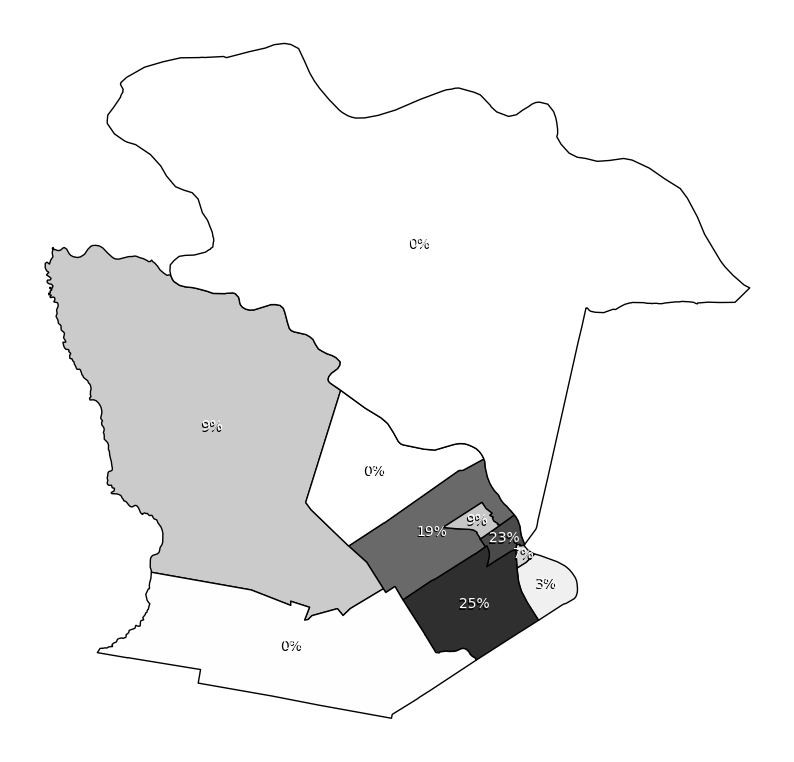

In [37]:
import matplotlib.pyplot as plt
ax = zarate.plot('Porcentaje', vmin=0, vmax=30, cmap='Greys', edgecolor='black', figsize = (10, 10))

# Add annotations in black
for x, y, label in zip(zarate.geometry.centroid.x, zarate.geometry.centroid.y, zarate['Porcentaje']):
    ax.text(x, y, f'{int(label)}%', color='black', ha='center', va='center')

offset_x = .001; offset_y = .001
# Add annotations in white (slightly offset for visibility)
for x, y, label in zip(zarate.geometry.centroid.x, zarate.geometry.centroid.y, zarate['Porcentaje']):
    ax.text(x + offset_x, y + offset_y, f'{int(label)}%', color='white', ha='center', va='center')

# Show the plot
plt.axis('off')
plt.show()

In [38]:
# Group by relevant levels and calculate the percentage
percentage_table = tabla.groupby(level=['año', 'eleccion_tag', 'cargo_nombre']).transform(lambda x: x / x.sum() * 100)

# Group by the same levels and sum the percentages
# sum_of_percentages = percentage_table.groupby(level=['año', 'eleccion_tag', 'cargo_nombre']).sum()
percentage_table.loc[tabla.sum(1) > 15000][main_circs.index].round().astype(int)

circuito_id                                                                                                                    001013  \
año  eleccion_tag cargo_nombre                         agrupacion_nombre                              lista_numero votos_tipo           
2011 GRAL11n      Concejal                             Nuevo Zarate                                   0            POSITIVO        64   
                  Diputado Nacional                    Alianza Frente para la Victoria                0            POSITIVO        55   
                  Gobernador                           Alianza Frente para la Victoria                0            POSITIVO        58   
                  Presidente                           Alianza Frente para la Victoria                0            POSITIVO        53   
                  Senador Nacional                     Alianza Frente para la Victoria                0            POSITIVO        54   
                  Senador Provincial                   Alianza Frente para la Victoria                0            POSITIVO        57   
2013 GRAL13n      Diputado Nacional                    FRENTE PARA LA VICTORIA                        0            POSITIVO        26   
                                                       FRENTE RENOVADOR                               0            POSITIVO        44   
                  Intendente                           FRENTE RENOVADOR                               0            POSITIVO        34   
     PASO13n      Diputado Nacional                    FRENTE PARA LA VICTORIA                        3323.0       POSITIVO        26   
                                                       FRENTE RENOVADOR                               3307.0       POSITIVO        37   
                  Diputado Provincial                  FRENTE PARA LA VICTORIA                        3323.0       POSITIVO        27   
                                                       FRENTE RENOVADOR                               3307.0       POSITIVO        34   
                  Intendente                           FRENTE RENOVADOR                               3307.0       POSITIVO        33   
2015 BLTG15n      Presidente                           CAMBIEMOS                                      0            POSITIVO        58   
                                                       FRENTE PARA LA VICTORIA                        0            POSITIVO        42   
     GRAL15n      Concejal                             NUEVO ZARATE                                   0            POSITIVO        42   
                  Diputado Nacional                    ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO        32   
                                                       CAMBIEMOS BUENOS AIRES                         0            POSITIVO        40   
                  Gobernador                           ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO        31   
                                                       CAMBIEMOS BUENOS AIRES                         0            POSITIVO        45   
                  Parlamentarios Mercosur Nacionales   ALIANZA CAMBIEMOS                              0            POSITIVO        39   
                                                       ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO        33   
                  Parlamentarios Mercosur Provinciales ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO        33   
                                                       CAMBIEMOS BUENOS AIRES                         0            POSITIVO        40   
                  Presidente                           ALIANZA CAMBIEMOS                              0            POSITIVO        39   
                                                       ALIANZA FRENTE PARA LA VICTORIA                0            POSITIVO        32   
                           

In [39]:
percentage_table.to_csv('./municipal/porcentaje_circs_zarate.csv')

## Mesas

In [40]:
mesas = pd.read_csv('./../datos/BD/mesas_table.csv')
mesas = mesas.loc[(mesas.distrito_id == 2) & (mesas.seccion_id == 125)].merge(eleccion)
mesas.groupby(['circuito_id', 'mesa_id'])['mesa_electores'].describe() # chequear numeros de electores de mesas.
mesa_electores = mesas.groupby(['circuito_id', 'mesa_id'])['mesa_electores'].median().reset_index()

In [42]:
votos_mesa = data.groupby(['eleccion_id', 'cargo_id', 'votos_tipo', 'agrupacion_nombre', 'lista_numero', 'circuito_id', 'mesa_id'])['votos_cantidad'].sum().reset_index()

# Merge with the 'eleccion' and 'cargo' table
votos_mesa = votos_mesa.merge(eleccion, on='eleccion_id', how='left').merge(cargo, on='cargo_id', how='left')
# agrups_lista = agrups_lista.fillna('')

tabla = votos_mesa.set_index(['año', 'eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_numero', 'votos_tipo', 'circuito_id', 'mesa_id'])['votos_cantidad'].unstack()
# tabla.loc[tabla.POSITIVO > 40000][['POSITIVO', 'BLANCO']].astype(int)
tabla


mesa_id                                                                                              1     \
año  eleccion_tag cargo_nombre       agrupacion_nombre          lista_numero votos_tipo circuito_id         
2011 GRAL11n      Concejal           Alianza Compromiso Federal 0            POSITIVO   001013        6.0   
                                                                                        001014        NaN   
                                                                                        001015        NaN   
                                                                                        001016        NaN   
                                                                                        001017        NaN   
...                                                                                                   ...   
2023 PASO23n      Senador Provincial VOCACION SOCIAL            3621         POSITIVO   001017        NaN   
                                                                                        001018        NaN   
                                                                                        001019        NaN   
                                                                                        001020        NaN   
                                                                                        001021        NaN   

mesa_id                                                                                              2     \
año  eleccion_tag cargo_nombre       agrupacion_nombre          lista_numero votos_tipo circuito_id         
2011 GRAL11n      Concejal           Alianza Compromiso Federal 0            POSITIVO   001013        NaN   
                                                                                        001014        NaN   
                                                                                        001015        NaN   
                                                                                        001016        NaN   
                                                                                        001017        NaN   
...                                                                                                   ...   
2023 PASO23n      Senador Provincial VOCACION SOCIAL            3621         POSITIVO   001017        NaN   
                                                                                        001018        NaN   
                                                                                        001019        NaN   
                                                                                        001020        NaN   
                                                                                        001021        NaN   

mesa_id                                                                                              3     \
año  eleccion_tag cargo_nombre       agrupacion_nombre          lista_numero votos_tipo circuito_id         
2011 GRAL11n      Concejal           Alianza Compromiso Federal 0            POSITIVO   001013        7.0   
                                                                                        001014        NaN   
                                                                                        001015        NaN   
                                                                                        001016        NaN   
                                                                                        001017        NaN   
...                                                                                                   ...   
2023 PASO23n      Senador Provincial VOCACION SOCIAL            3621         POSITIVO   001017        NaN   
                                                                                        001018        NaN   
                                                                          

In [43]:
data[['circuito_id', 'mesa_id']].drop_duplicates().shape

(465, 2)

In [44]:
datos_mesa = votos_mesa.merge(mesa_electores)

In [47]:
tabla = votos_circuito.set_index(['año', 'eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_numero', 'votos_tipo', 'circuito_id'])['votos_cantidad'].unstack()
# top = tabla.loc[tabla.index.get_level_values('cargo_nombre').isin(['Diputado Nacional', 'Presidente'])].loc[tabla.sum(1) > 6000]
top = tabla.loc[tabla.sum(1) > 3000]


In [48]:
# datos_mesa

datos = top.index.to_frame(index = False).merge(datos_mesa)
# datos = datos_mesa

# Tabla mesas versus votos de las listas
# datos.groupby(['eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_nombre', 'circuito_id', 'mesa_id'])['votos_cantidad'].sum().unstack(['circuito_id', 'mesa_id'])
tabla = datos.pivot_table(values='votos_cantidad',
                  index=['eleccion_tag', 'cargo_nombre', 'agrupacion_nombre', 'lista_numero'],
                  columns=['circuito_id', 'mesa_id'],
                  aggfunc='sum')

tabla.head()

circuito_id                                                              001013  \
mesa_id                                                                    1      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             142.0   
                          FRENTE PARA LA VICTORIA           0             129.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0              29.0   
                          Alianza Frente para la Victoria   0              43.0   
                          Nuevo Zarate                      0             158.0   

circuito_id                                                                      \
mesa_id                                                                    2      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             194.0   
                          FRENTE PARA LA VICTORIA           0             102.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0               NaN   
                          Alianza Frente para la Victoria   0               NaN   
                          Nuevo Zarate                      0               NaN   

circuito_id                                                                      \
mesa_id                                                                    3      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             168.0   
                          FRENTE PARA LA VICTORIA           0             132.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0              20.0   
                          Alianza Frente para la Victoria   0              48.0   
                          Nuevo Zarate                      0             168.0   

circuito_id                                                                      \
mesa_id                                                                    4      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             147.0   
                          FRENTE PARA LA VICTORIA           0             125.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0              23.0   
                          Alianza Frente para la Victoria   0              40.0   
                          Nuevo Zarate                      0             155.0   

circuito_id                                                                      \
mesa_id                                                                    5      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             159.0   
                          FRENTE PARA LA VICTORIA           0             123.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0              33.0   
                          Alianza Frente para la Victoria   0              42.0   
                          Nuevo Zarate                      0             154.0   

circuito_id                                                                      \
mesa_id                                                                    6      
eleccion_tag cargo_nombre agrupacion_nombre                 lista_numero          
BLTG15n      Presidente   CAMBIEMOS                         0             152.0   
                          FRENTE PARA LA VICTORIA           0             137.0   
GRAL11n      Concejal     Alianza Frente Amplio Progresista 0              27.0   
                          Alianza Frente para la Victoria   0              47.0   
                          Nuevo Zarate                      0             158.0   

circuito_i

In [49]:
# tabla.T.corr().round(1)


In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

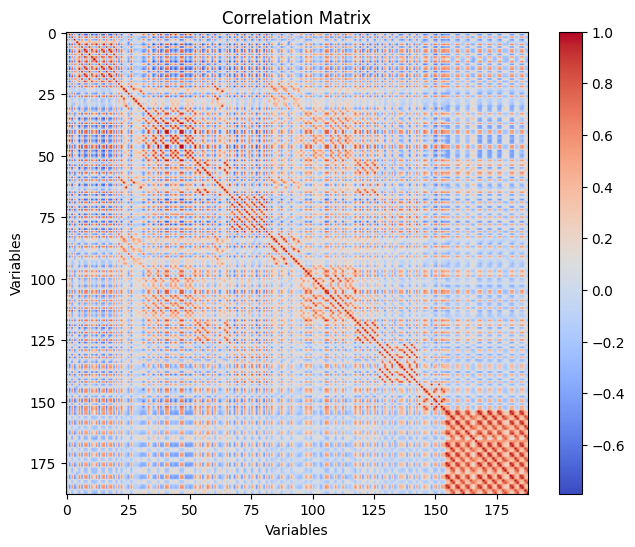

In [52]:
# Assuming 'tabla' is your square pandas DataFrame
corr_matrix = tabla.T.corr().values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Generate the matrix image plot
im = ax.imshow(corr_matrix, cmap='coolwarm')

# Add a colorbar
cbar = ax.figure.colorbar(im, ax=ax)

# Set the title and labels
ax.set_title('Correlation Matrix')
plt.xlabel('Variables')
plt.ylabel('Variables')

# Show the plot
plt.show()


In [77]:
from scipy.cluster.hierarchy import fcluster, linkage
import pandas as pd

# Perform the hierarchical clustering
clusters = linkage(1 - corr_matrix, 'complete')
# Define the labels based on a distance threshold or a number of clusters
labels = fcluster(clusters, t=6.0, criterion='distance')

# Suppose you have the list of political lists in a variable named 'political_lists'
df = tabla.index.to_frame(index = False)
df["nombre"] = df.apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
political_lists = df["nombre"].tolist()

# Create a DataFrame to relate the political list with its cluster
df_clusters = pd.DataFrame({'political_list': political_lists, 'cluster': labels})

# Now df_clusters contains each political list along with its assigned cluster. 
# You can group by 'cluster' to see the political lists within each cluster:
clusters_groups = df_clusters.groupby('cluster')['political_list'].apply(list)


/tmp/ipykernel_242789/1651051555.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  clusters = linkage(1 - corr_matrix, 'complete')


In [78]:
df_clusters.groupby('cluster').cluster.value_counts()

cluster
1    46
2    69
3    50
4    23
Name: count, dtype: int64

In [63]:
pd.options.display.max_colwidth = 9999

In [79]:
print(df_clusters.sample(40).groupby('cluster').political_list.unique().values)

[array(['PASO13n Intendente FRENTE PARA LA VICTORIA 3323.0',
        'GRAL17n Diputado Provincial UNIDAD CIUDADANA 0',
        'GRAL11n Presidente Alianza Frente para la Victoria 0',
        'GRAL19n Intendente FRENTE DE TODOS 0',
        'GRAL11n Concejal Alianza Frente para la Victoria 0',
        'PASO15n Senador Provincial ALIANZA FRENTE PARA LA VICTORIA 3403.0',
        'GRAL19n Gobernador FRENTE DE TODOS 0',
        'GRAL17n Senador Nacional UNIDAD CIUDADANA 0',
        'PASO19n Gobernador FRENTE DE TODOS 2',
        'GRAL17n Diputado Provincial FRENTE PARA LA VICTORIA 0',
        'GRAL17n Diputado Nacional UNIDAD CIUDADANA 0',
        'GRAL13n Diputado Nacional FRENTE PARA LA VICTORIA 0',
        'GRAL19n Diputado Nacional FRENTE DE TODOS 0'], dtype=object)
 array(['PASO15n Diputado Nacional ALIANZA CAMBIEMOS 3182.0',
        'PASO13n Diputado Nacional FRENTE PROGRESISTA CIVICO Y SOCIAL 3310.0',
        'PASO19n Presidente JUNTOS POR EL CAMBIO A',
        'PASO15n Presidente ALI

In [ ]:
# data.merge(eleccion).groupby(['eleccion_tag', 'agrupacion_nombre', 'lista_nombre', 'cargo_id'])['votos_cantidad'].sum().unstack(['cargo_id'])
votos = data.groupby(['eleccion_id', 'agrupacion_nombre', 'lista_nombre', 'cargo_id'])['votos_cantidad'].sum()
main = votos.loc[votos > 8500].reset_index().rename(columns = {'votos_cantidad': 'lista_votos'})

In [ ]:
out_info = main.merge(df, how = 'left').merge(df_clusters, left_on = 'nombre', right_on = 'political_list')
# out_info.groupby(['eleccion_tag', 'agrupacion_nombre', 'lista_nombre', 'cluster']).size().shape
clusters_listas = out_info.groupby(['eleccion_id', 'agrupacion_nombre', 'lista_nombre', 'cargo_id', 'lista_votos']).cluster.apply(lambda x: x.value_counts().index[0])

clusters_listas = clusters_listas.reset_index().sort_values(by = ['cluster', 'lista_votos'])
clusters_listas = clusters_listas.merge(eleccion).merge(cargo)
clusters_listas.to_csv('./municipal/historico_listas_zarate.csv', index = False)

clusters_listas

,eleccion_id,agrupacion_nombre,lista_nombre,cargo_id,lista_votos,cluster,año,eleccion_tipo,recuento_tipo,padron_tipo,eleccion_tag,cargo_nombre,cargo_tag
0,3,FRENTE SOCIAL DE LA PROVINCIA DE BUENOS AIRES,LINEA BLANCA Y CELESTE - 4,7,8753,1,2013,PASO,PROVISORIO,NORMAL,PASO13n,Concejal,IN
1,3,FRENTE RENOVADOR,CORRIENTE RENOVADORA - LISTA 1,7,17297,3,2013,PASO,PROVISORIO,NORMAL,PASO13n,Concejal,IN
2,14,FRENTE DE TODOS,CELESTE Y BLANCA - 2,7,34891,1,2019,PASO,PROVISORIO,NORMAL,PASO19n,Concejal,IN
3,14,JUNTOS POR EL CAMBIO,3A - ROJO,7,9397,2,2019,PASO,PROVISORIO,NORMAL,PASO19n,Concejal,IN
4,14,JUNTOS POR EL CAMBIO,1A - AMARILLO,7,11489,2,2019,PASO,PROVISORIO,NORMAL,PASO19n,Concejal,IN
5,3,FRENTE PARA LA VICTORIA,LISTA 2 - CELESTE Y BLANCA K,6,19635,1,2013,PASO,PROVISORIO,NORMAL,PASO13n,Diputado Provincial,DP
6,3,FRENTE PROGRESISTA CIVICO Y SOCIAL,UNIDAD PROGRESISTA - A,6,8667,2,2013,PASO,PROVISORIO,NORMAL,PASO13n,Diputado Provincial,DP
7,3,FRENTE RENOVADOR,CORRIENTE RENOVADORA - LISTA 1,6,19797,3,2013,PASO,PROVISORIO,NORMAL,PASO13n,Diputado Provincial,DP
8,16,FRENTE DE TODOS,CELESTE Y BLANCA 2,6,18940,1,2021,PASO,PROVISORIO,NORMAL,PASO21n,Diputado Provincial,DP
9,16,JUNTOS,DAR EL PASO,6,8596,2,2021,PASO,PROVISORIO,NORMAL,PASO21n,Diputado Provincial,DP


In [ ]:
df = data.merge(clusters_listas).merge(eleccion[['eleccion_id', 'eleccion_tag']]).merge(cargo[['cargo_id', 'cargo_tag']])

# df = df.loc[df.cluster.isin([1, 2])]

votos_circ_mesa = df.set_index(['circuito_id', 'mesa_id', 'eleccion_tag', 'agrupacion_nombre', 'lista_nombre', 'cargo_tag', 'cluster']).votos_cantidad
tabla = votos_circ_mesa.unstack(['circuito_id', 'mesa_id'])
# df.groupby(['circuito_id', 'mesa_id', 'eleccion_id', 'eleccion_tag', 'agrupacion_nombre', 'lista_nombre', 'cargo_id', 'cargo_tag', 'agrupacion_nombre', 'lista_nombre', 'votos_tipo']).nunique().max()

tabla[main_circs.index]

circuito_id                                                                                                              001013  \
mesa_id                                                                                                                     2     
eleccion_tag agrupacion_nombre                              lista_nombre                               cargo_tag cluster          
GRAL15n      ALIANZA FRENTE PARA LA VICTORIA                ALIANZA FRENTE PARA LA VICTORIA            CO        1         29.0   
             CAMBIEMOS BUENOS AIRES                         CAMBIEMOS BUENOS AIRES                     CO        2        106.0   
             NUEVO ZARATE                                   NUEVO ZARATE                               CO        3        108.0   
PASO13n      FRENTE PARA LA VICTORIA                        LISTA 2 - CELESTE Y BLANCA K               DN        1         63.0   
                                                                                                       DP        1         57.0   
             FRENTE RENOVADOR                               CORRIENTE RENOVADORA - LISTA 1             DN        3         93.0   
                                                                                                       DP        3         88.0   
                                                                                                       IN        3         75.0   
PASO15n      ALIANZA CAMBIEMOS                              LISTA G EL CAMINO DEL CAMBIO               DN        2        106.0   
                                                                                                       MP        2        105.0   
                                                                                                       PR        2         99.0   
                                                            LISTA H CAMBIEMOS EL PAIS                  MN        2        113.0   
             ALIANZA FRENTE PARA LA VICTORIA                A LISTA CELESTE Y BLANCA K NESTOR KIRCHNER DN        1         67.0   
                                                                                                       MN        1         67.0   
                                                                                                       MP        1         64.0   
                                                                                                       PR        1         68.0   
                                                            LISTA CELESTE Y BLANCA K 1                 GB        1         43.0   
                                                            LISTA CELESTE Y BLANCA K 10                GB        1         31.0   
                                                            LISTA CELESTE Y BLANCA K 2                 SP        1         64.0   
             ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA) A FRENTE RENOVADOR +A15                    DN        3         47.0   
                                                                                                       GB        3         44.0   
                                                                                                       MN        3         46.0   
                                                                                                       MP        3         45.0   
                                                                                                       PR        3         50.0   
                                                                                                       SP        3         44.0   
             CAMBIEMOS BUENOS AIRES                         LISTA 1 A AMARILLO                         GB        2        115.0   
                                                                                                       SP        2        114.0   
PASO17n      1PAIS                                          UN PAIS UN

In [ ]:
## Tabla, quantiles de mesa, vs quantiles del partido.

In [ ]:
info = data[['eleccion_id', 'cargo_id', 'circuito_id', 'mesa_id', 'agrupacion_nombre', 'lista_nombre', 'votos_cantidad']]
votos_zarate = info.groupby(['eleccion_id', 'cargo_id', 'agrupacion_nombre', 'lista_nombre'])['votos_cantidad'].sum(); votos_zarate.name = 'total_zarate' #.add_suffix('_sum').reset_index()
votos_zarate = votos_zarate.reset_index().merge(cargo).merge(eleccion)[['eleccion_tag', 'agrupacion_nombre', 'lista_nombre', 'cargo_tag', 'total_zarate']]
votos_zarate

,eleccion_tag,agrupacion_nombre,lista_nombre,cargo_tag,total_zarate
0,PASO13n,COMPROMISO FEDERAL,ES POSIBLE - E,DN,411
1,PASO13n,COMPROMISO FEDERAL,ES POSIBLE BUENOS AIRES - P,DN,9
2,PASO13n,COMPROMISO FEDERAL,JUSTICIA Y DIGNIDAD - M,DN,174
3,PASO13n,COMPROMISO FEDERAL,UNIR - U,DN,1500
4,PASO13n,FRENTE PARA LA VICTORIA,LISTA 2 - CELESTE Y BLANCA K,DN,19900
...,...,...,...,...,...
289,GRAL15n,ALIANZA FRENTE PARA LA VICTORIA,ALIANZA FRENTE PARA LA VICTORIA,CO,13679
290,GRAL15n,ALIANZA PROGRESISTAS,ALIANZA PROGRESISTAS,CO,1564
291,GRAL15n,ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA),ALIANZA UNIDOS POR UNA NUEVA ALTERNATIVA (UNA),CO,9846
292,GRAL15n,CAMBIEMOS BUENOS AIRES,CAMBIEMOS BUENOS AIRES,CO,13700


In [ ]:
info = votos_circ_mesa.reset_index()
info = info.merge(votos_zarate, how = 'left')

# cl = 1 # FpV 1, JxC 2, Massa 3.
# info_cluster = info.loc[info.cluster == cl]

In [ ]:
def fit_line_through_origin(group):
    x = group['votos_cantidad']
    y = group['total_zarate']
    # Calculate the slope of the line through the origin
    slope = (x * y).sum() / (x**2).sum()
    return slope


# Group the data by circuito_id, mesa_id, and cluster
groups = info.groupby(['circuito_id', 'mesa_id', 'cluster'])

# Apply the fit_line_through_origin function to each group
slopes = groups.apply(fit_line_through_origin).reset_index()

# Rename the calculated column to 'slope'
slopes.rename(columns={0: 'slope'}, inplace=True)

# Resulting DataFrame 'slopes' now contains the slope of the line that fits votos_cantidad vs. total_zarate for each group


In [ ]:
slopes

,circuito_id,mesa_id,cluster,slope
0,001013,1,1,293.379828
1,001013,1,2,206.561193
2,001013,1,3,216.832960
3,001013,2,1,379.533637
4,001013,2,2,143.086282
...,...,...,...,...
1095,01013A,60,2,1062.432432
1096,01013A,60,3,983.261658
1097,01013A,63,1,363.651047
1098,01013A,63,2,959.222727


In [ ]:
out = slopes.set_index(['circuito_id', 'mesa_id', 'cluster']).unstack(-1).round(1)
out

In [ ]:
xx

In [ ]:
.to_csv('./municipal/convers_mesa_zarate.csv')

In [ ]:
xx

In [ ]:
info = slopes.copy()

import numpy as np
values = np.arange(10000, 30001, 2500)

# Calculate the new columns by dividing each value by the slope
for val in values:
    info[str(val)] = np.round(val / info['slope']).astype(int)

In [ ]:
for cluster_n in [1, 2, 3]:
    show = info.loc[info['cluster'] == cluster_n].groupby(['circuito_id', 'mesa_id']).first().drop(['cluster', 'slope'], axis = 1)
    show.to_csv('./municipal/mesa_testigo_cluster_' + str(cluster_n) + '.csv')
    display(show)


SyntaxError: unterminated string literal (detected at line 3) (1362474377.py, line 3)

In [ ]:



# info_cluster['total_zarate_'] = pd.cut(info_cluster['total_zarate'], 8, duplicates = 'drop')

# def format_bins(value):
#     # Extracting the bin edges
#     left, right = value.left, value.right

#     # Rounding to the nearest 100 and converting to integer
#     left, right = int(round(left, -2)), int(round(right, -2))

#     # Returning the formatted string 'a - b'
#     return f'{left} - {right}'

# # Applying the function to the index of the result DataFrame
# # result.index = result.index.categories.map(format_bins)

# info_cluster['total_zarate_'] = info_cluster['total_zarate_'].apply(format_bins)

# quantiles_result = info_cluster.groupby(['cluster', 'circuito_id', 'mesa_id', 'total_zarate_'])['votos_cantidad'].mean()

/tmp/ipykernel_28732/3212709829.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_cluster['total_zarate_'] = pd.cut(info_cluster['total_zarate'], 8, duplicates = 'drop')
/tmp/ipykernel_28732/3212709829.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  info_cluster['total_zarate_'] = info_cluster['total_zarate_'].apply(format_bins)


In [ ]:
# result = quantiles_result.unstack([-1]).dropna(axis = 1, how = 'all').dropna()

# result = result.sort_index(axis = 1)
# result.round(0).astype(int)
# #.unstack(-1).dropna(how = 'all')

In [ ]:
# tabla.T.describe().T.sort_values('mean').tail(50)

In [ ]:
# largest_rows.shape
# (40, 395)

In [ ]:
# Calculate row sums
row_sums = tabla.sum(axis=1)

# Sort rows by sums in descending order
sorted_rows = tabla.loc[row_sums.sort_values(ascending=False).index]

# Select the largest rows by sum
largest_rows = sorted_rows.head(40)

# Extract the cluster values from the index
clusters = largest_rows.index.get_level_values('cluster')

# Define color mapping for clusters
color_map = {
    1: '#ADD8E6',  # dark blue
    2: '#00008B',  # light blue
    3: '#FFFF00',  # yellow
    4: '#A52A2A',  # brown
    5: '#A52A2A'   # dark green
}

# Create a list of colors based on the clusters
colors = [color_map[cluster] for cluster in clusters]


# Create a horizontal box plot
plt.figure(figsize=(8, 20))
bp = largest_rows.T.boxplot(vert=False, patch_artist=True, return_type='dict')

# Iterate over boxes and change their color
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.5)  # Add transparency. Change this value as you need
    box.set_edgecolor('k')

# # Create a horizontal box plot
# plt.figure(figsize=(8, 20))
# largest_rows.T.boxplot(vert=False)
plt.title('Distribution of Columns in Largest Rows by Sum')
plt.xlabel('Values')
plt.ylabel('Columns')
plt.show()


KeyError: 'Level cluster not found'

<Axes: >

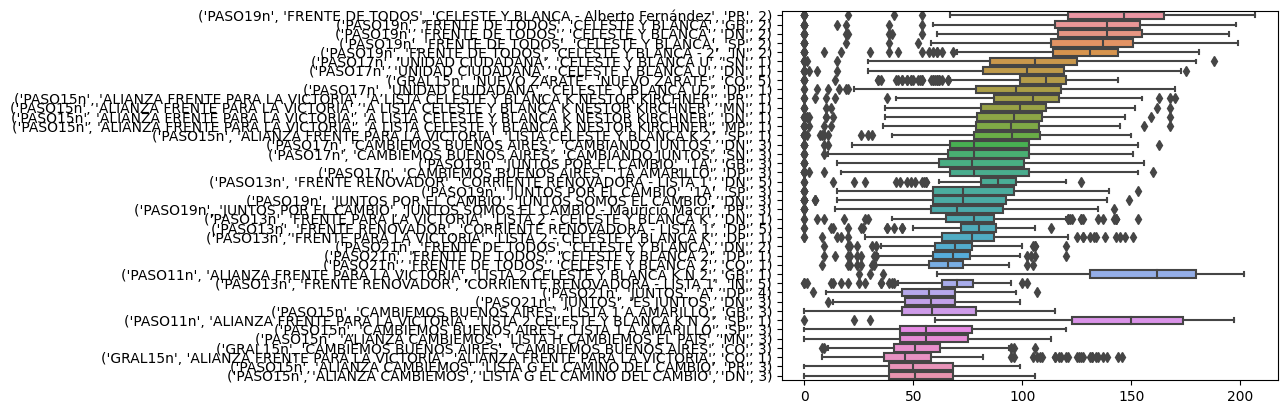

In [ ]:
sns.boxplot(largest_rows.T, orient='h')

<Axes: >

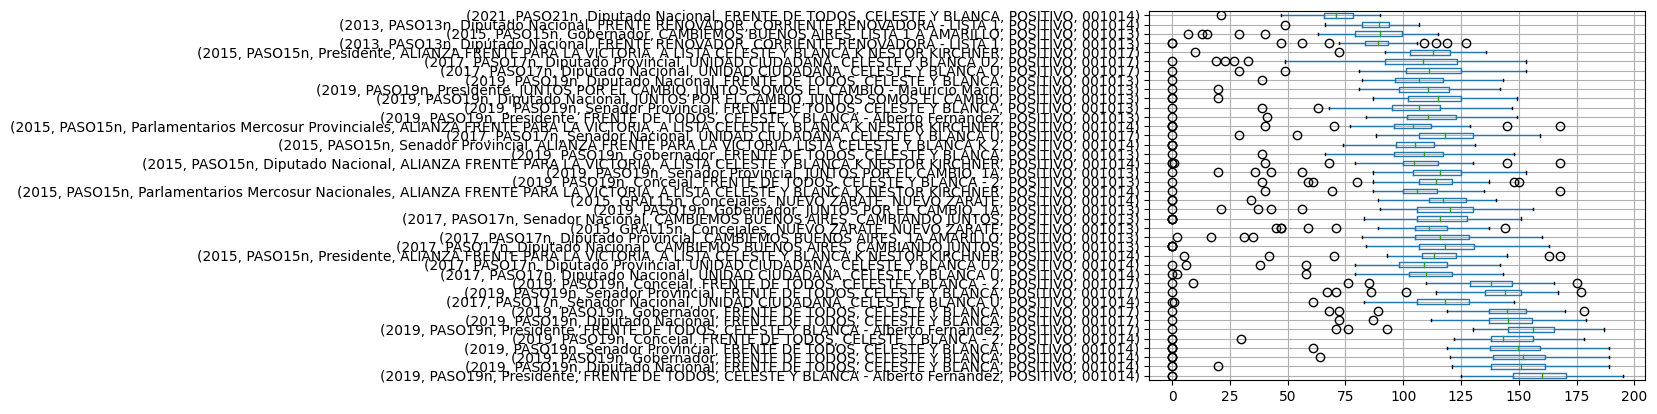

In [ ]:
largest_rows.T.boxplot(vert=False)


In [ ]:
pd.options.display.max_colwidth = 300

In [ ]:
clusters_groups

NameError: name 'clusters_groups' is not defined

<Axes: >

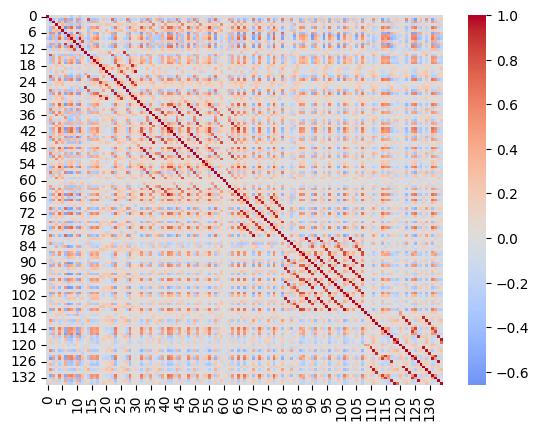

In [ ]:
import seaborn as sns

sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

#### Porcentaje de votos que obtuvieron las fuerzas en cada circuito.

In [ ]:
df = pd.read_csv('./municipal/porcentaje_circs_zarate.csv')
show = df.drop(['votos_tipo', '001019', '001020', '01013A'], axis = 1).round(1)

show = show.loc[(show.select_dtypes(include=['float64']).mean(1) > 10)]
show = show.loc[show.cargo_nombre.isin(['Diputado Nacional', 'Presidente'])]

show

,año,eleccion_tag,cargo_nombre,agrupacion_nombre,lista_nombre,001013,001014,001015,001016,001017,001018,001021
14,2013,PASO13n,Diputado Nacional,FRENTE PARA LA VICTORIA,LISTA 2 - CELESTE Y B...,26.3,34.1,27.3,26.8,34.6,31.4,48.7
15,2013,PASO13n,Diputado Nacional,FRENTE PROGRESISTA CI...,UNIDAD PROGRESISTA - A,20.7,9.5,17.6,15.9,11.5,12.8,9.2
16,2013,PASO13n,Diputado Nacional,FRENTE RENOVADOR,CORRIENTE RENOVADORA ...,36.7,37.0,36.3,40.3,35.7,39.0,29.9
17,2013,PASO13n,Diputado Nacional,UNIDOS POR LA LIBERTA...,LISTA CELESTE,13.0,13.7,12.7,14.0,13.4,13.2,8.2
33,2015,PASO15n,Diputado Nacional,ALIANZA CAMBIEMOS,LISTA G EL CAMINO DEL...,33.3,18.2,29.9,29.6,17.6,22.9,15.7
37,2015,PASO15n,Diputado Nacional,ALIANZA FRENTE PARA L...,A LISTA CELESTE Y BLA...,32.8,47.1,35.3,33.5,44.0,39.4,58.2
41,2015,PASO15n,Diputado Nacional,ALIANZA UNIDOS POR UN...,A FRENTE RENOVADOR +A15,20.0,24.1,20.2,20.6,23.3,26.1,16.7
94,2015,PASO15n,Presidente,ALIANZA CAMBIEMOS,LISTA G EL CAMINO DEL...,29.3,17.8,27.6,26.2,16.8,20.6,13.5
98,2015,PASO15n,Presidente,ALIANZA FRENTE PARA L...,A LISTA CELESTE Y BLA...,32.1,45.4,34.2,37.2,46.0,40.0,58.9
101,2015,PASO15n,Presidente,ALIANZA UNIDOS POR UN...,A FRENTE RENOVADOR +A15,18.9,22.6,18.9,19.8,23.0,24.6,14.4


#### Cantidad de votos que obtuvieron las fuerzas en cada circuito.

In [ ]:
df = pd.read_csv('./municipal/agrups_main_circ_zarate.csv')
show = df.drop(['votos_tipo', '001019', '001020', '01013A'], axis = 1).round(-1)
show.drop('año', axis = 1)

,eleccion_tag,cargo_nombre,agrupacion_nombre,lista_nombre,001013,001014,001015,001016,001017,001018,001021
0,PASO13n,Diputado Nacional,FRENTE PARA LA VICTORIA,LISTA 2 - CELESTE Y B...,3980,5060,1340,460,4050,1940,2960
1,PASO13n,Diputado Nacional,FRENTE RENOVADOR,CORRIENTE RENOVADORA ...,5550,5480,1780,680,4180,2410,1820
2,PASO15n,Diputado Nacional,ALIANZA CAMBIEMOS,LISTA G EL CAMINO DEL...,4740,2510,1460,570,1990,1380,760
3,PASO15n,Diputado Nacional,ALIANZA FRENTE PARA L...,A LISTA CELESTE Y BLA...,4670,6500,1720,640,4990,2360,2830
4,PASO15n,Diputado Nacional,ALIANZA UNIDOS POR UN...,A FRENTE RENOVADOR +A15,2840,3330,990,390,2630,1570,810
5,PASO15n,Presidente,ALIANZA CAMBIEMOS,LISTA G EL CAMINO DEL...,4580,2840,1460,540,2040,1340,710
6,PASO15n,Presidente,ALIANZA FRENTE PARA L...,A LISTA CELESTE Y BLA...,5010,7240,1800,760,5570,2600,3080
7,PASO15n,Presidente,ALIANZA UNIDOS POR UN...,A FRENTE RENOVADOR +A15,2950,3610,1000,410,2790,1600,750
8,PASO17n,Diputado Nacional,CAMBIEMOS BUENOS AIRES,CAMBIANDO JUNTOS,7090,4800,2170,940,3900,2180,1690
9,PASO17n,Diputado Nacional,UNIDAD CIUDADANA,CELESTE Y BLANCA U,4350,7650,1610,860,6070,2570,3830
